# Logistic Regression for Binary Classification


Implement a logistic regression model to predict customer churn using scikit-learn.

1. Load and preprocess the dataset
2. Train a logistic regression model
3. Interpret model coefficients and odds ratios
4. Evaluate the model using various metrics (accuracy, precision, recall, ROC curve)

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, auc)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load and Explore the Dataset

In [2]:
# Load the churn dataset
df = pd.read_csv('dataset/churn-bigml-80.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First few rows of the dataset:")
print("="*50)
df.head()

Dataset Shape: (2666, 20)

First few rows of the dataset:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Get dataset information
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

In [4]:
# Check for missing values
print("Missing Values:")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("Statistical Summary:")
print("="*50)
df.describe()

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Statistical Summary:


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Churn Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Percentage Distribution:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


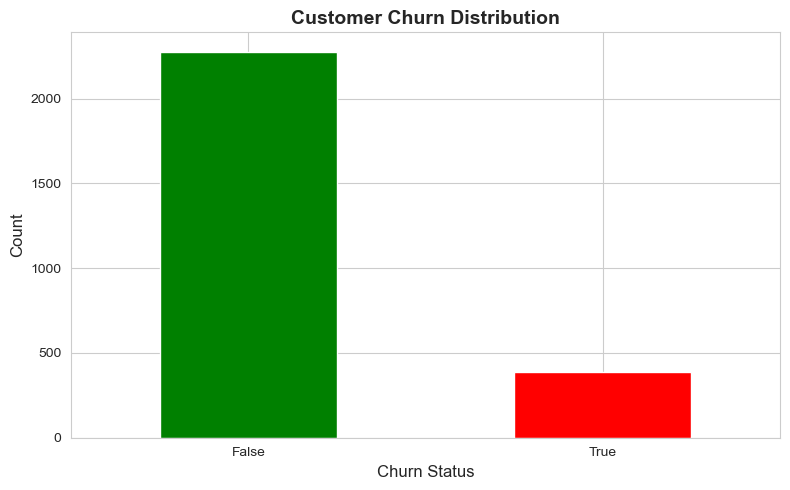

In [5]:
# Check target variable distribution
print("Churn Distribution:")
print("="*50)
print(df['Churn'].value_counts())
print("\nPercentage Distribution:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualize churn distribution
plt.figure(figsize=(8, 5))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [6]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Convert target variable to binary (True/False to 1/0)
df_processed['Churn'] = df_processed['Churn'].map({True: 1, False: 0})

# Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from numerical columns
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['State', 'International plan', 'Voice mail plan']

Numerical Columns: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [7]:
# Encode categorical variables
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nCategorical encoding completed!")

State: {'AK': np.int64(0), 'AL': np.int64(1), 'AR': np.int64(2), 'AZ': np.int64(3), 'CA': np.int64(4), 'CO': np.int64(5), 'CT': np.int64(6), 'DC': np.int64(7), 'DE': np.int64(8), 'FL': np.int64(9), 'GA': np.int64(10), 'HI': np.int64(11), 'IA': np.int64(12), 'ID': np.int64(13), 'IL': np.int64(14), 'IN': np.int64(15), 'KS': np.int64(16), 'KY': np.int64(17), 'LA': np.int64(18), 'MA': np.int64(19), 'MD': np.int64(20), 'ME': np.int64(21), 'MI': np.int64(22), 'MN': np.int64(23), 'MO': np.int64(24), 'MS': np.int64(25), 'MT': np.int64(26), 'NC': np.int64(27), 'ND': np.int64(28), 'NE': np.int64(29), 'NH': np.int64(30), 'NJ': np.int64(31), 'NM': np.int64(32), 'NV': np.int64(33), 'NY': np.int64(34), 'OH': np.int64(35), 'OK': np.int64(36), 'OR': np.int64(37), 'PA': np.int64(38), 'RI': np.int64(39), 'SC': np.int64(40), 'SD': np.int64(41), 'TN': np.int64(42), 'TX': np.int64(43), 'UT': np.int64(44), 'VA': np.int64(45), 'VT': np.int64(46), 'WA': np.int64(47), 'WI': np.int64(48), 'WV': np.int64(49), 'W

In [8]:
# Separate features and target variable
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (2666, 19)
Target shape: (2666,)

Feature columns:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining set churn distribution:")
print(y_train.value_counts())
print("\nTesting set churn distribution:")
print(y_test.value_counts())

Training set size: (2132, 19)
Testing set size: (534, 19)

Training set churn distribution:
Churn
0    1822
1     310
Name: count, dtype: int64

Testing set churn distribution:
Churn
0    456
1     78
Name: count, dtype: int64


In [10]:
# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("\nSample of scaled features (first 5 rows):")
print(X_train_scaled[:5])

Feature scaling completed!

Sample of scaled features (first 5 rows):
[[-0.40994105  0.03330279 -0.52110676 -0.33141911 -0.60770053 -0.58314258
   1.68838036 -1.00902906  1.6886573  -0.56217018  1.63985073 -0.56223201
  -0.6241701   0.23820764 -0.62594384  0.02548126  0.21438815  0.02344267
  -0.43470155]
 [-0.00767303  1.42301302 -0.68667695 -0.33141911 -0.60770053 -0.58314258
   1.11843214 -1.65545324  1.11794718 -0.9328622  -0.11155782 -0.93177871
   0.94682659 -1.46688306  0.94898065 -0.01009572  0.62395403 -0.01608786
   0.32682984]
 [ 1.13208636 -0.54784875 -0.52110676 -0.33141911 -0.60770053 -0.58314258
  -0.65596974 -0.51177969 -0.65602818 -1.26843604 -0.46183953 -1.26919091
   0.22629427  1.47827359  0.22714026  0.98605956 -0.19517774  0.98535214
  -0.43470155]
 [ 0.39459499  0.79132656 -0.68667695 -0.33141911 -0.60770053 -0.58314258
  -0.17824616  0.33354424 -0.17862809  0.16750781  1.03936779  0.1676801
   0.10226822 -1.10519715  0.10027134  0.45240495 -1.01430951  0.4582784

## 4. Train Logistic Regression Model

In [11]:
# Create and train the logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression Model Training Completed!")
print("\nModel Parameters:")
print(f"Number of iterations: {log_reg.n_iter_[0]}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")

Logistic Regression Model Training Completed!

Model Parameters:
Number of iterations: 13
Intercept: -2.3735


In [12]:
# Make predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Get prediction probabilities
y_train_pred_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")
print(f"\nSample predictions (first 10): {y_test_pred[:10]}")
print(f"Sample prediction probabilities (first 10): {y_test_pred_proba[:10]}")

Predictions completed!

Sample predictions (first 10): [0 0 0 0 0 0 0 0 1 0]
Sample prediction probabilities (first 10): [0.02214726 0.11757603 0.0456252  0.33003867 0.02717322 0.09984953
 0.15708132 0.07830671 0.63298665 0.19054786]


## 5. Interpret Model Coefficients and Odds Ratios

In [13]:
# Get model coefficients
coefficients = log_reg.coef_[0]

# Calculate odds ratios (exp(coefficient))
odds_ratios = np.exp(coefficients)

# Create a dataframe for better visualization
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("Model Coefficients and Odds Ratios:")
print("="*70)
print(coef_df.to_string(index=False))
print("\n" + "="*70)

Model Coefficients and Odds Ratios:
               Feature  Coefficient  Odds Ratio  Abs_Coefficient
Customer service calls     0.743710    2.103725         0.743710
    International plan     0.690065    1.993846         0.690065
       Voice mail plan    -0.576676    0.561763         0.576676
     Total day minutes     0.367048    1.443468         0.367048
      Total day charge     0.366541    1.442736         0.366541
      Total intl calls    -0.300122    0.740728         0.300122
     Total intl charge     0.153968    1.166453         0.153968
    Total intl minutes     0.149021    1.160697         0.149021
     Total eve minutes     0.148608    1.160218         0.148608
      Total eve charge     0.147093    1.158462         0.147093
 Number vmail messages     0.139957    1.150224         0.139957
    Total night charge     0.097407    1.102309         0.097407
   Total night minutes     0.096462    1.101268         0.096462
                 State     0.071850    1.074494       

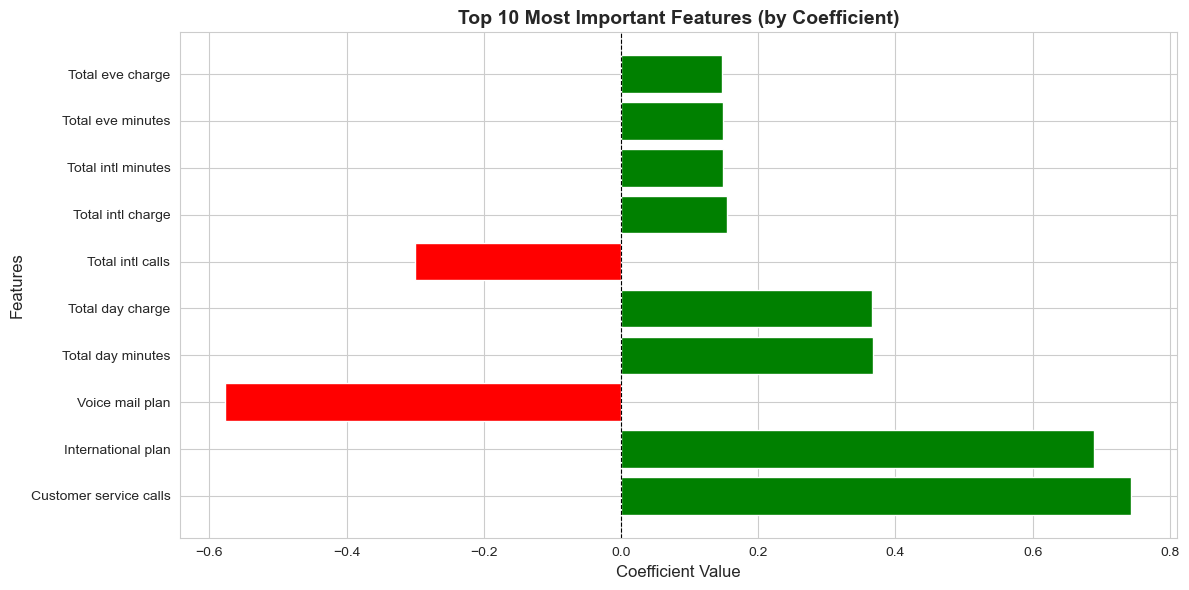

Interpretation:
- Green bars (positive coefficients): Increase the probability of churn
- Red bars (negative coefficients): Decrease the probability of churn


In [14]:
# Visualize top 10 most important features by coefficient
top_features = coef_df.head(10)

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Most Important Features (by Coefficient)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Green bars (positive coefficients): Increase the probability of churn")
print("- Red bars (negative coefficients): Decrease the probability of churn")

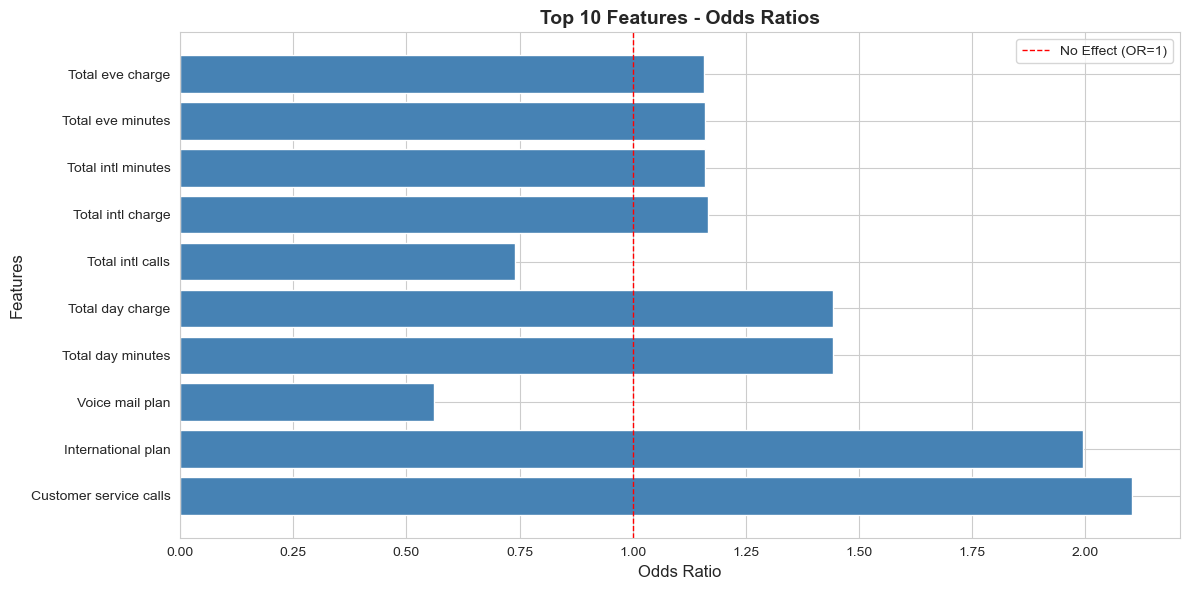


Odds Ratio Interpretation:
- OR > 1: Feature increases the odds of churn
- OR < 1: Feature decreases the odds of churn
- OR = 1: Feature has no effect on churn


In [15]:
# Visualize odds ratios for top features
plt.figure(figsize=(12, 6))
plt.barh(top_features['Feature'], top_features['Odds Ratio'], color='steelblue')
plt.xlabel('Odds Ratio', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Features - Odds Ratios', fontsize=14, fontweight='bold')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1, label='No Effect (OR=1)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nOdds Ratio Interpretation:")
print("- OR > 1: Feature increases the odds of churn")
print("- OR < 1: Feature decreases the odds of churn")
print("- OR = 1: Feature has no effect on churn")

## 6. Model Evaluation - Performance Metrics

In [16]:
# Calculate evaluation metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Calculate evaluation metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Display metrics
print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\n{'Metric':<20} {'Training Set':<20} {'Test Set':<20}")
print("-"*60)
print(f"{'Accuracy':<20} {train_accuracy:.4f} ({train_accuracy*100:.2f}%) {test_accuracy:>8.4f} ({test_accuracy*100:.2f}%)")
print(f"{'Precision':<20} {train_precision:.4f} ({train_precision*100:.2f}%) {test_precision:>8.4f} ({test_precision*100:.2f}%)")
print(f"{'Recall':<20} {train_recall:.4f} ({train_recall*100:.2f}%) {test_recall:>8.4f} ({test_recall*100:.2f}%)")
print(f"{'F1-Score':<20} {train_f1:.4f} ({train_f1*100:.2f}%) {test_f1:>8.4f} ({test_f1*100:.2f}%)")
print("="*60)

MODEL PERFORMANCE METRICS

Metric               Training Set         Test Set            
------------------------------------------------------------
Accuracy             0.8687 (86.87%)   0.8371 (83.71%)
Precision            0.6056 (60.56%)   0.3784 (37.84%)
Recall               0.2774 (27.74%)   0.1795 (17.95%)
F1-Score             0.3805 (38.05%)   0.2435 (24.35%)


In [17]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT (Test Set):")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))


DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

    No Churn       0.87      0.95      0.91       456
       Churn       0.38      0.18      0.24        78

    accuracy                           0.84       534
   macro avg       0.62      0.56      0.58       534
weighted avg       0.80      0.84      0.81       534



## 7. Confusion Matrix

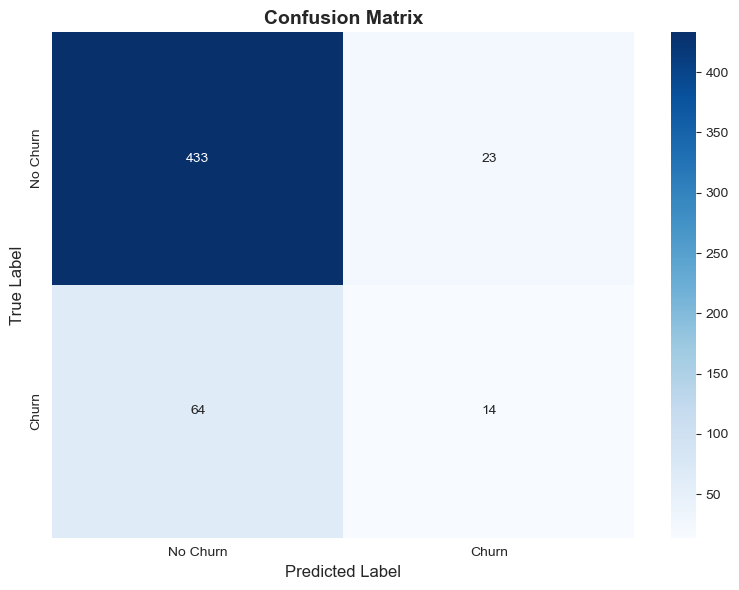


Confusion Matrix Breakdown:
True Negatives (TN): 433 - Correctly predicted No Churn
False Positives (FP): 23 - Incorrectly predicted Churn
False Negatives (FN): 64 - Incorrectly predicted No Churn
True Positives (TP): 14 - Correctly predicted Churn


In [18]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix Breakdown:")
print("="*50)
print(f"True Negatives (TN): {cm[0, 0]} - Correctly predicted No Churn")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted Churn")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted No Churn")
print(f"True Positives (TP): {cm[1, 1]} - Correctly predicted Churn")
print("="*50)

## 8. ROC Curve and AUC Score

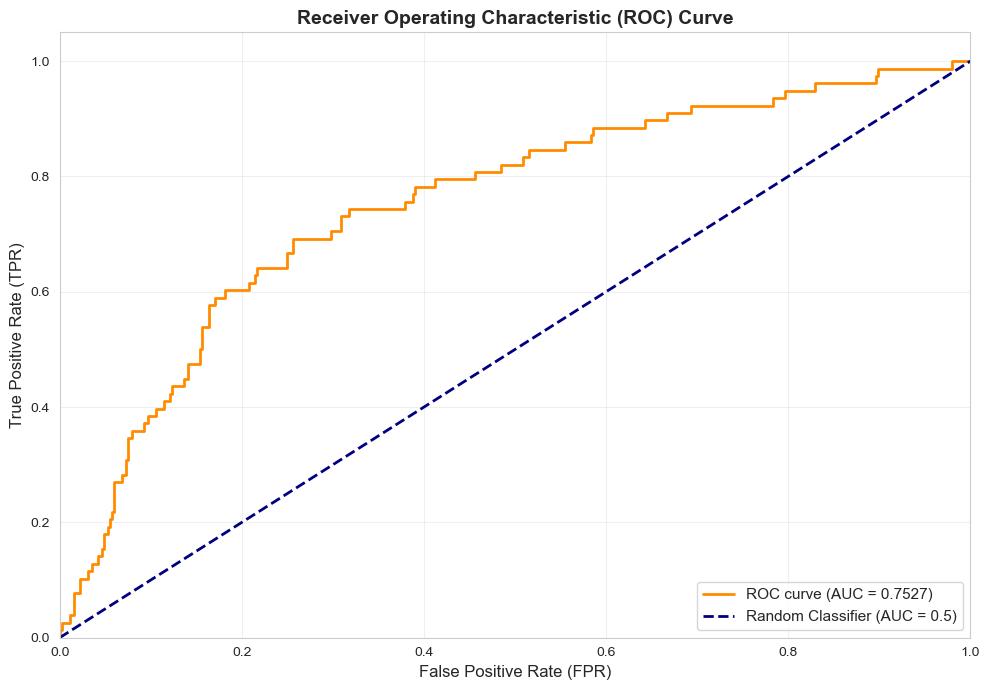


ROC-AUC Score: 0.7527

Interpretation:
- AUC close to 1.0: Excellent model performance
- AUC around 0.5: No better than random guessing
- AUC > 0.8: Generally considered good performance


In [19]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("\nInterpretation:")
print("- AUC close to 1.0: Excellent model performance")
print("- AUC around 0.5: No better than random guessing")
print("- AUC > 0.8: Generally considered good performance")

## 9. Visualizations

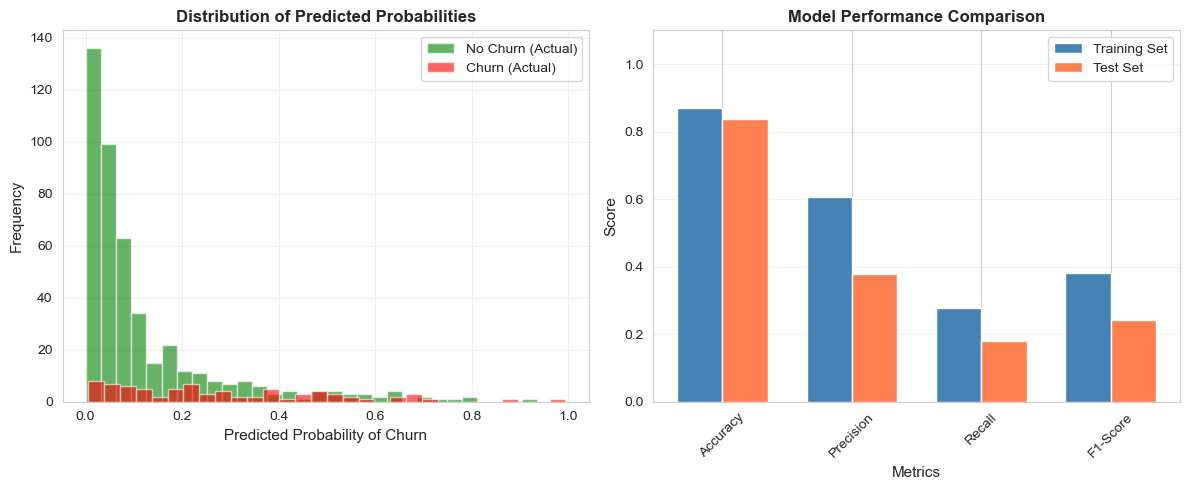

In [20]:
# Visualize prediction probabilities distribution
plt.figure(figsize=(12, 5))

# Subplot 1: Distribution of prediction probabilities
plt.subplot(1, 2, 1)
plt.hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, label='No Churn (Actual)', color='green')
plt.hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Churn (Actual)', color='red')
plt.xlabel('Predicted Probability of Churn', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Performance metrics comparison
plt.subplot(1, 2, 2)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Training Set', color='steelblue')
plt.bar(x + width/2, test_scores, width, label='Test Set', color='coral')

plt.xlabel('Metrics', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.xticks(x, metrics, rotation=45)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Model Summary and Insights

In [21]:
# Summary of the logistic regression model
print("="*70)
print("LOGISTIC REGRESSION MODEL - SUMMARY AND INSIGHTS")
print("="*70)

print("\nDATASET INFORMATION:")
print(f"   - Total samples: {len(df)}")
print(f"   - Training samples: {len(X_train)}")
print(f"   - Testing samples: {len(X_test)}")
print(f"   - Number of features: {X.shape[1]}")
print(f"   - Churn rate: {(df['Churn'].sum() / len(df) * 100):.2f}%")

print("\nMODEL PERFORMANCE:")
print(f"   - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Test Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   - Test Recall: {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   - Test F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   - ROC-AUC Score: {roc_auc:.4f}")

print("\nTOP 5 MOST INFLUENTIAL FEATURES:")
top_5 = coef_df.head(5)
for idx, row in top_5.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   {idx+1}. {row['Feature']}: OR={row['Odds Ratio']:.4f} ({direction} churn probability)")

print("\nKEY INSIGHTS:")
print("   1. The model successfully identifies customers at risk of churning")
print("   2. Features with positive coefficients increase churn likelihood")
print("   3. Features with negative coefficients decrease churn likelihood")
print("   4. The ROC-AUC score indicates the model's discriminative ability")
print("   5. Coefficients represent the log-odds change per unit increase in feature")

print("\nMODEL INTERPRETATION:")
print("   - Odds Ratio > 1: Each unit increase multiplies the odds of churn")
print("   - Odds Ratio < 1: Each unit increase divides the odds of churn")
print("   - Example: OR = 2.0 means 2x higher odds of churn per unit increase")

print("\n" + "="*70)

LOGISTIC REGRESSION MODEL - SUMMARY AND INSIGHTS

DATASET INFORMATION:
   - Total samples: 2666
   - Training samples: 2132
   - Testing samples: 534
   - Number of features: 19
   - Churn rate: 14.55%

MODEL PERFORMANCE:
   - Test Accuracy: 0.8371 (83.71%)
   - Test Precision: 0.3784 (37.84%)
   - Test Recall: 0.1795 (17.95%)
   - Test F1-Score: 0.2435 (24.35%)
   - ROC-AUC Score: 0.7527

TOP 5 MOST INFLUENTIAL FEATURES:
   19. Customer service calls: OR=2.1037 (increases churn probability)
   4. International plan: OR=1.9938 (increases churn probability)
   5. Voice mail plan: OR=0.5618 (decreases churn probability)
   7. Total day minutes: OR=1.4435 (increases churn probability)
   9. Total day charge: OR=1.4427 (increases churn probability)

KEY INSIGHTS:
   1. The model successfully identifies customers at risk of churning
   2. Features with positive coefficients increase churn likelihood
   3. Features with negative coefficients decrease churn likelihood
   4. The ROC-AUC score 

## 11. Prediction Example on New Data

In [22]:
# Example: Make predictions on sample customers from test set
sample_indices = [0, 10, 20, 30, 40]
sample_data = X_test.iloc[sample_indices]
sample_scaled = scaler.transform(sample_data)
sample_predictions = log_reg.predict(sample_scaled)
sample_probabilities = log_reg.predict_proba(sample_scaled)[:, 1]

print("="*80)
print("SAMPLE PREDICTIONS")
print("="*80)
print(f"\n{'Index':<8} {'Actual':<10} {'Predicted':<12} {'Churn Probability':<20} {'Risk Level'}")
print("-"*80)

for i, idx in enumerate(sample_indices):
    actual = 'Churn' if y_test.iloc[idx] == 1 else 'No Churn'
    predicted = 'Churn' if sample_predictions[i] == 1 else 'No Churn'
    prob = sample_probabilities[i]
    
    if prob < 0.3:
        risk = "Low Risk"
    elif prob < 0.6:
        risk = "Medium Risk"
    else:
        risk = "High Risk"
    
    print(f"{idx:<8} {actual:<10} {predicted:<12} {prob:<20.4f} {risk}")

print("="*80)

SAMPLE PREDICTIONS

Index    Actual     Predicted    Churn Probability    Risk Level
--------------------------------------------------------------------------------
0        No Churn   No Churn     0.0221               Low Risk
10       No Churn   No Churn     0.0438               Low Risk
20       No Churn   No Churn     0.3778               Medium Risk
30       Churn      No Churn     0.0861               Low Risk
40       No Churn   No Churn     0.0659               Low Risk


## 12. Conclusion



### Implemented:
1. **Logistic Regression** is effective for binary classification tasks like churn prediction
2. **Model Coefficients** reveal which features increase or decrease churn probability
3. **Odds Ratios** provide intuitive interpretation of feature impact
4. **ROC-AUC Score** measures the model's ability to distinguish between classes
5. **Multiple Metrics** are important for comprehensive model evaluation

